### ___Multi Response Phylogenetic Mixed Models `MR-PMM` using Markov Chain Monte Carlo generalized linear mixed models `MCMCglmm`___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [2]:
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html

In [3]:
set.seed(2026 - 3 - 9)

suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("MCMCglmm")
    library("nlme")
    library("U.PhyloMaker")
    library("phylolm")
    library("geiger")
})

### ___1. Phylogeny___
---------------------------

In [10]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/final_name_matched.csv") # FRED 4.0 subset with names reconciled with the megatree by hand
# this does not need programmatic name reconciliations
traits$binominal <- gsub(traits$binominal, pattern = ' ', replacement = '_')
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [7]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = traits$binominal, genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [8]:
ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [22]:
stopifnot(all(traits[match(phy$phylo$tip.label, traits$binominal), ]$binominal == phy$phylo$tip.label))
traits <- traits[match(phy$phylo$tip.label, traits$binominal), ]
write.csv(traits, "../../data/chapter2/FRED/subsets/final_name_matched.csv", row.names = FALSE)

### ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [5]:
GEIGER_FITCONTINUOUS_MODEL_OPTIONS <- c("BM", "OU", "EB", "rate_trend", "lambda", "kappa", "delta", "mean_trend", "white")
PHYLOLM_PHYLOLM_MODEL_OPTIONS <- c("BM", "OUrandomRoot", "OUfixedRoot", "lambda", "kappa", "delta", "EB", # "trend", - "trend" option is problematic for ultrametric trees
                                   "GC")

In [15]:
# this phylogeny needs to be fully bifurcating with no polytomies
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301_species.tre") # the phylogeny of the 1301 FRED 4.0 subset species

In [16]:
if(!ape::is.binary(tree)) tree <- ape::multi2di(tree, random = FALSE) # split polytomies into binary 0 length branches

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches

# this must be done after altering the branch lengths
if (!ape::is.ultrametric(tree)) tree <- phytools::force.ultrametric(tree = tree, method = "extend") # this needs to be done after replacing the 0 length branches with small non zero noise

stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

traits <- read.csv("../../data/chapter2/FRED/subsets/final.csv", row.names = "binominal") # we need the binominal names as row names for phylolm::phylolm()

# repeat the taxonomic corrections
# traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
# traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"
# traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

# traits["binominal"] <- paste0(traits$F01286, '_', traits$F01287)
# stopifnot(length(traits$binominal)==length(tree$tip.label))
# stopifnot(sum(tree$tip.label %in% traits$binominal) == length(tree$tip.label))
# traits <- traits[match(tree$tip.label, traits$binominal), ] # name matching the dataset and the phylogeny

stopifnot(all(tree$tip.label==traits$binominal)) # the current traits dataset has already been name matched with the phylogeny!!!!!!!!

***************************************************************
*                          Note:                              *
*    force.ultrametric does not include a formal method to    *
*    ultrametricize a tree & should only be used to coerce    *
*   a phylogeny that fails is.ultrametric due to rounding --  *
*    not as a substitute for formal rate-smoothing methods.   *
***************************************************************


In [20]:
head(traits)

,F01286,F01289,F00679,F00727,F00709,state,state_source,synonym
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Ratibida_pinnata,Ratibida,Asteraceae,-0.8209806,4.025352,-2.120264,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Helianthus pinnatus', 'Obeliscaria pinnata')"
Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.9675840,4.158883,-1.966113,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
Liatris_aspera,Liatris,Asteraceae,-0.7985077,4.382027,-2.525729,AM,Maherali et. al. 2016,"('Lacinaria scariosa var. aspera', 'Lacinaria aspera')"
Arnica_sororia,Arnica,Asteraceae,-1.4134600,4.342257,-1.203973,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
Arnica_fulgens,Arnica,Asteraceae,-0.6627150,2.765172,-1.124452,AM,Maherali et. al. 2016,"('Arnica montana var. fulgens',)"
Hymenoxys_richardsonii,Hymenoxys,Asteraceae,-1.2644308,4.235371,-1.460061,AM,"(Soudzilovskaia et al., 2020)","('Picradenia richardsonii', 'Actinea richardsonii', 'Actinella richardsonii')"


In [17]:
# the tutorial uses the R library phylolm
# nlme::gls requires a correlation matrix - ape provides only limited options (Brownian, Bloomberg, Pagel et.c.) for this

suppressWarnings(
    rbind(
        SRL.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00679, data = traits, model = m, phy = tree)$aic), # SRL ~ RD
        RD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00727, data = traits, model = m, phy = tree)$aic) # RD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RD,4340.725,2917.8101,2917.8101,2342.3040,2532.9301,4237.162,4342.725,3036.2211
RD.SRL,2002.748,661.4962,661.4962,169.3322,405.0623,1901.315,2004.748,938.3773


In [18]:
suppressWarnings(
    rbind(
        SRL.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00727 ~ F00709, data = traits, model = m, phy = tree)$aic), # SRL ~ RTD
        RTD.SRL = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00727, data = traits, model = m, phy = tree)$aic) # RTD ~ SRL
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
SRL.RTD,4598.274,3506.664,3506.664,3016.570,3177.738,4499.339,4600.274,3645.258
RTD.SRL,3157.692,1992.819,1992.819,1544.616,1733.517,3058.137,3159.692,2177.964


In [19]:
suppressWarnings(
    rbind(
        RTD.RD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00709 ~ F00679, data = traits, model = m, phy = tree)$aic), # RTD ~ RD
        RD.RTD = mapply(PHYLOLM_PHYLOLM_MODEL_OPTIONS, FUN = function (m) phylolm::phylolm(F00679 ~ F00709, data = traits, model = m, phy = tree)$aic) # RD ~ RTD
    )
)

,BM,OUrandomRoot,OUfixedRoot,lambda,kappa,delta,EB,GC
RTD.RD,3754.571,2467.833,2467.833,1940.750,2097.042,3652.552,3756.571,2547.834
RD.RTD,2857.176,1725.364,1725.364,1239.566,1413.930,2757.907,2859.176,1917.285


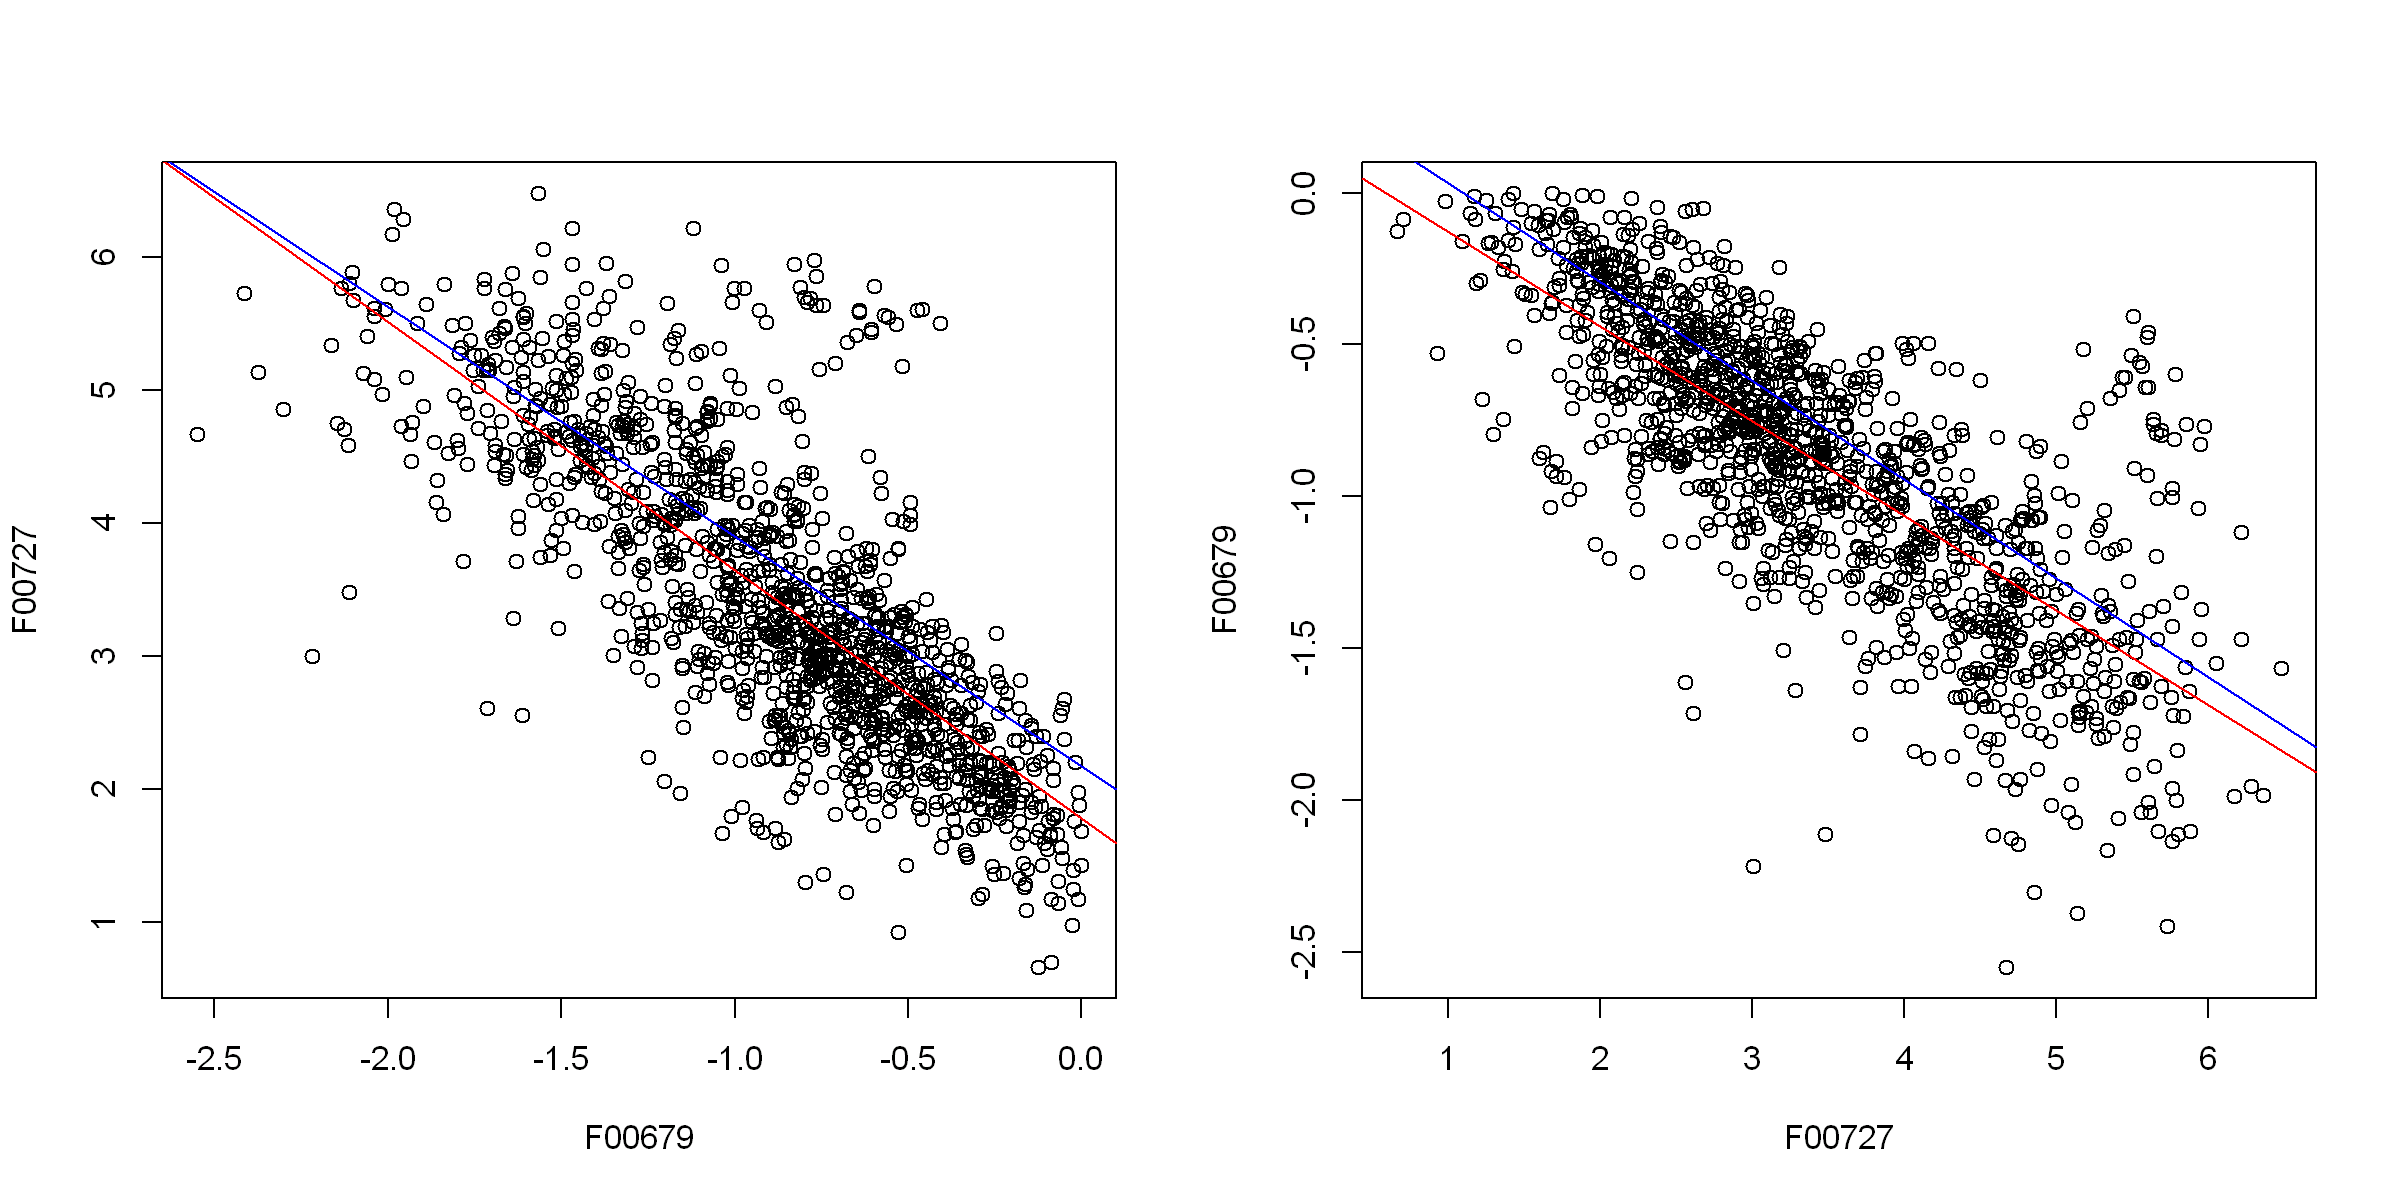

In [20]:
#------------
# SRL & RD
#------------

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
par(mfrow = c(1, 2))

plot(F00727 ~ F00679, data = traits)
abline(lm(F00727 ~ F00679, data = traits), col = "red")
abline(phylolm::phylolm(F00727 ~ F00679, data = traits, model = "lambda", phy = tree), col = "blue")

plot(F00679 ~ F00727, data = traits)
abline(lm(F00679 ~ F00727, data = traits), col = "red")
abline(phylolm::phylolm(F00679 ~ F00727, data = traits, model = "lambda", phy = tree), col = "blue")

# summary(modp)

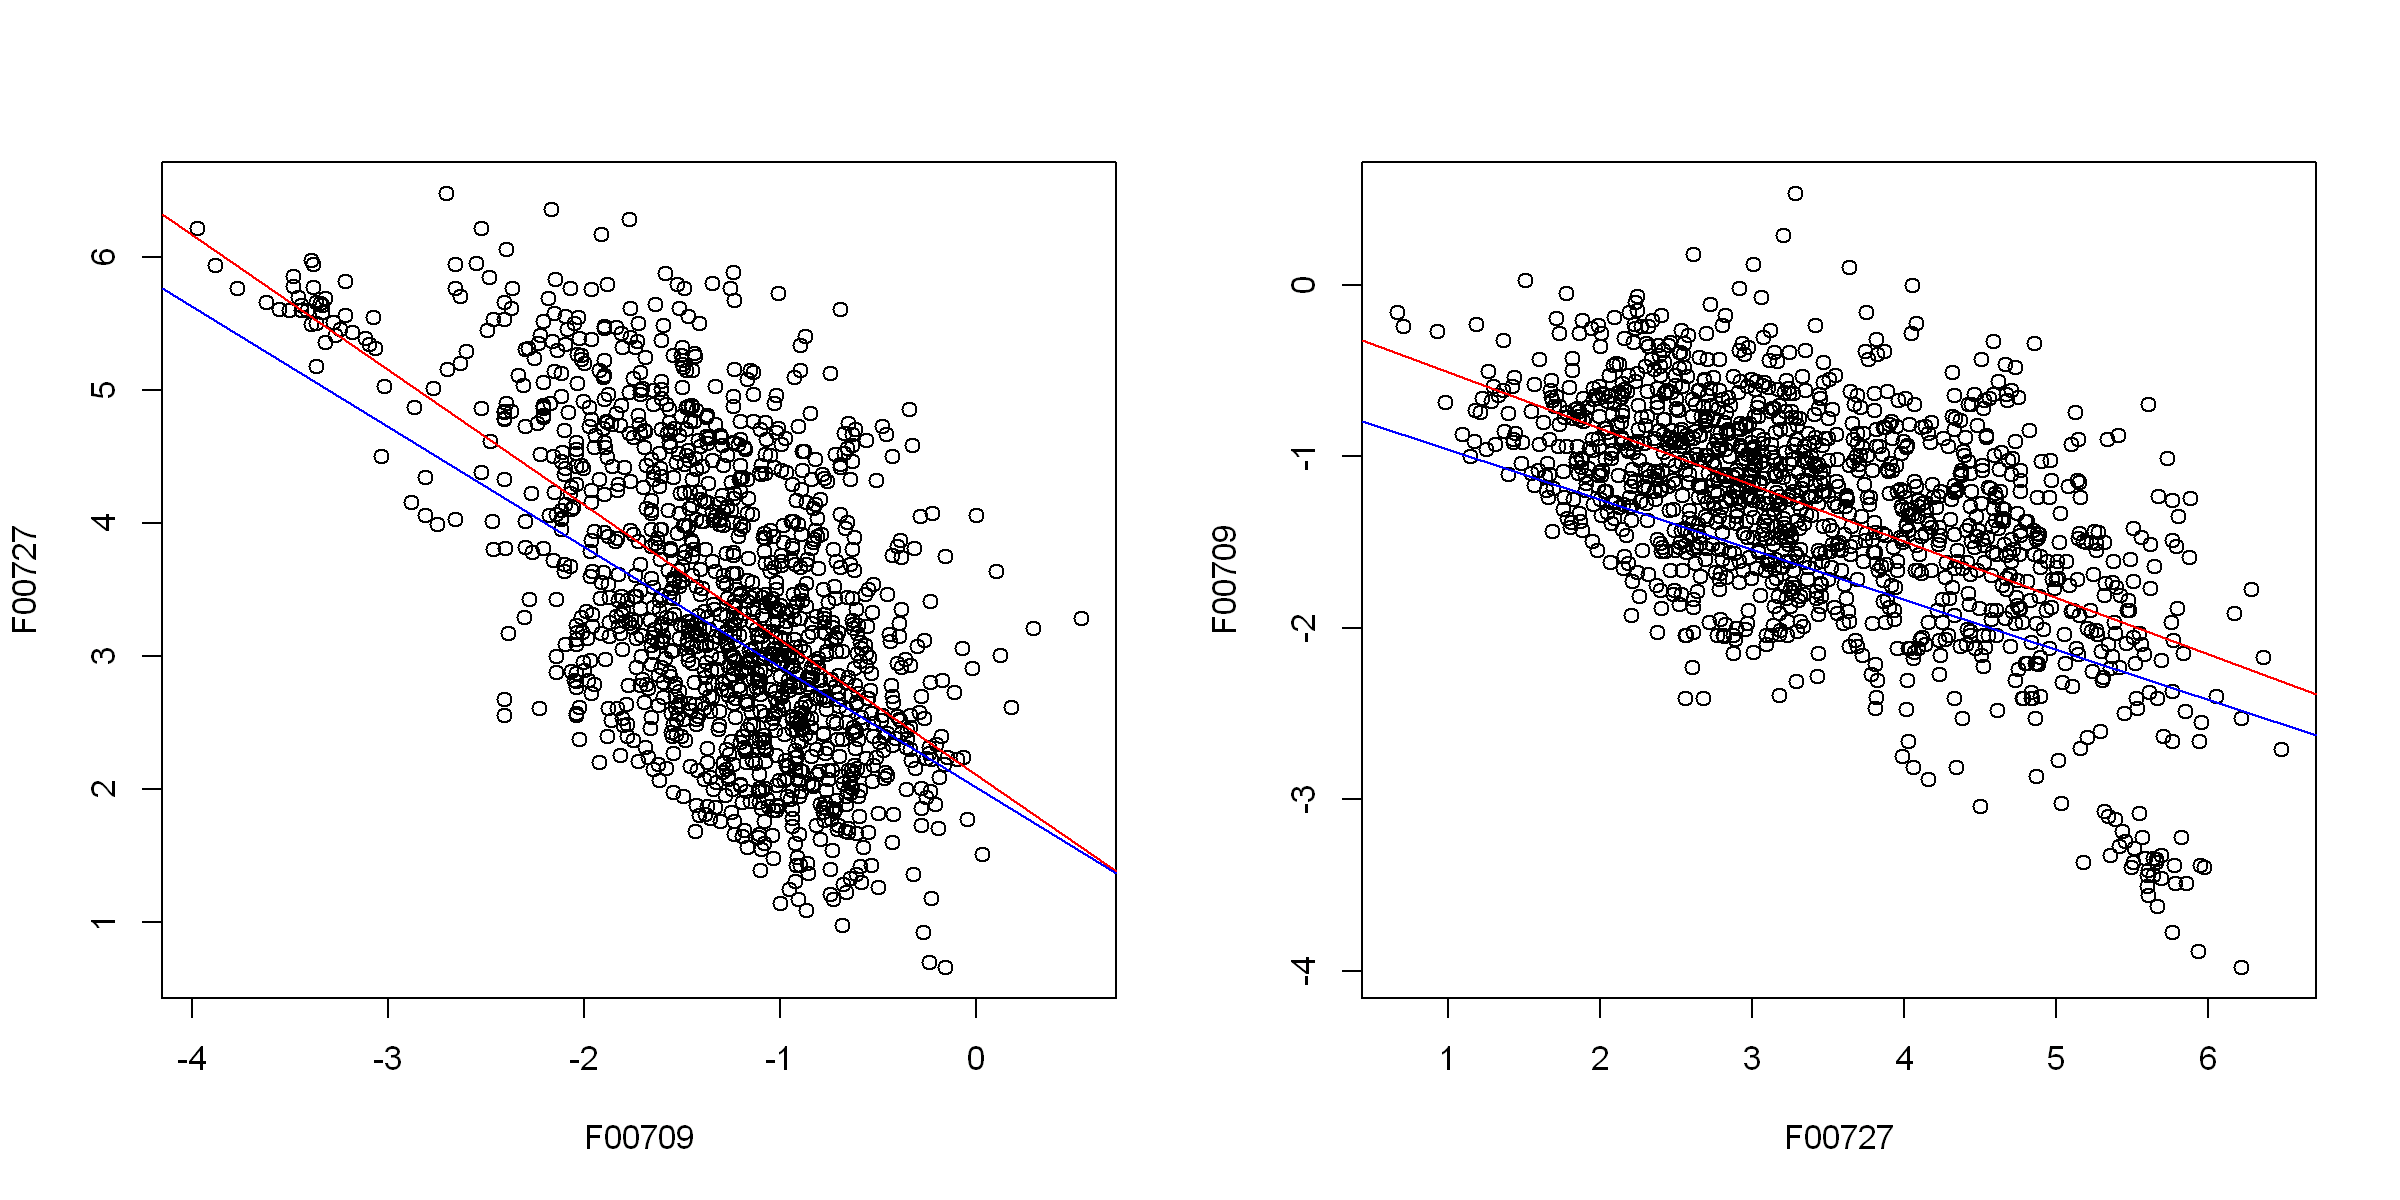

In [21]:
#------------
# SRL & RTD
#------------

par(mfrow = c(1, 2))
plot(F00727 ~ F00709, data = traits)
abline(lm(F00727 ~ F00709, data = traits), col = "red")
abline(phylolm::phylolm(F00727 ~ F00709, data = traits, model = "lambda", phy = tree), col = "blue")

plot(F00709 ~ F00727, data = traits)
abline(lm(F00709 ~ F00727, data = traits), col = "red")
abline(phylolm::phylolm(F00709 ~ F00727, data = traits, model = "lambda", phy = tree), col = "blue")

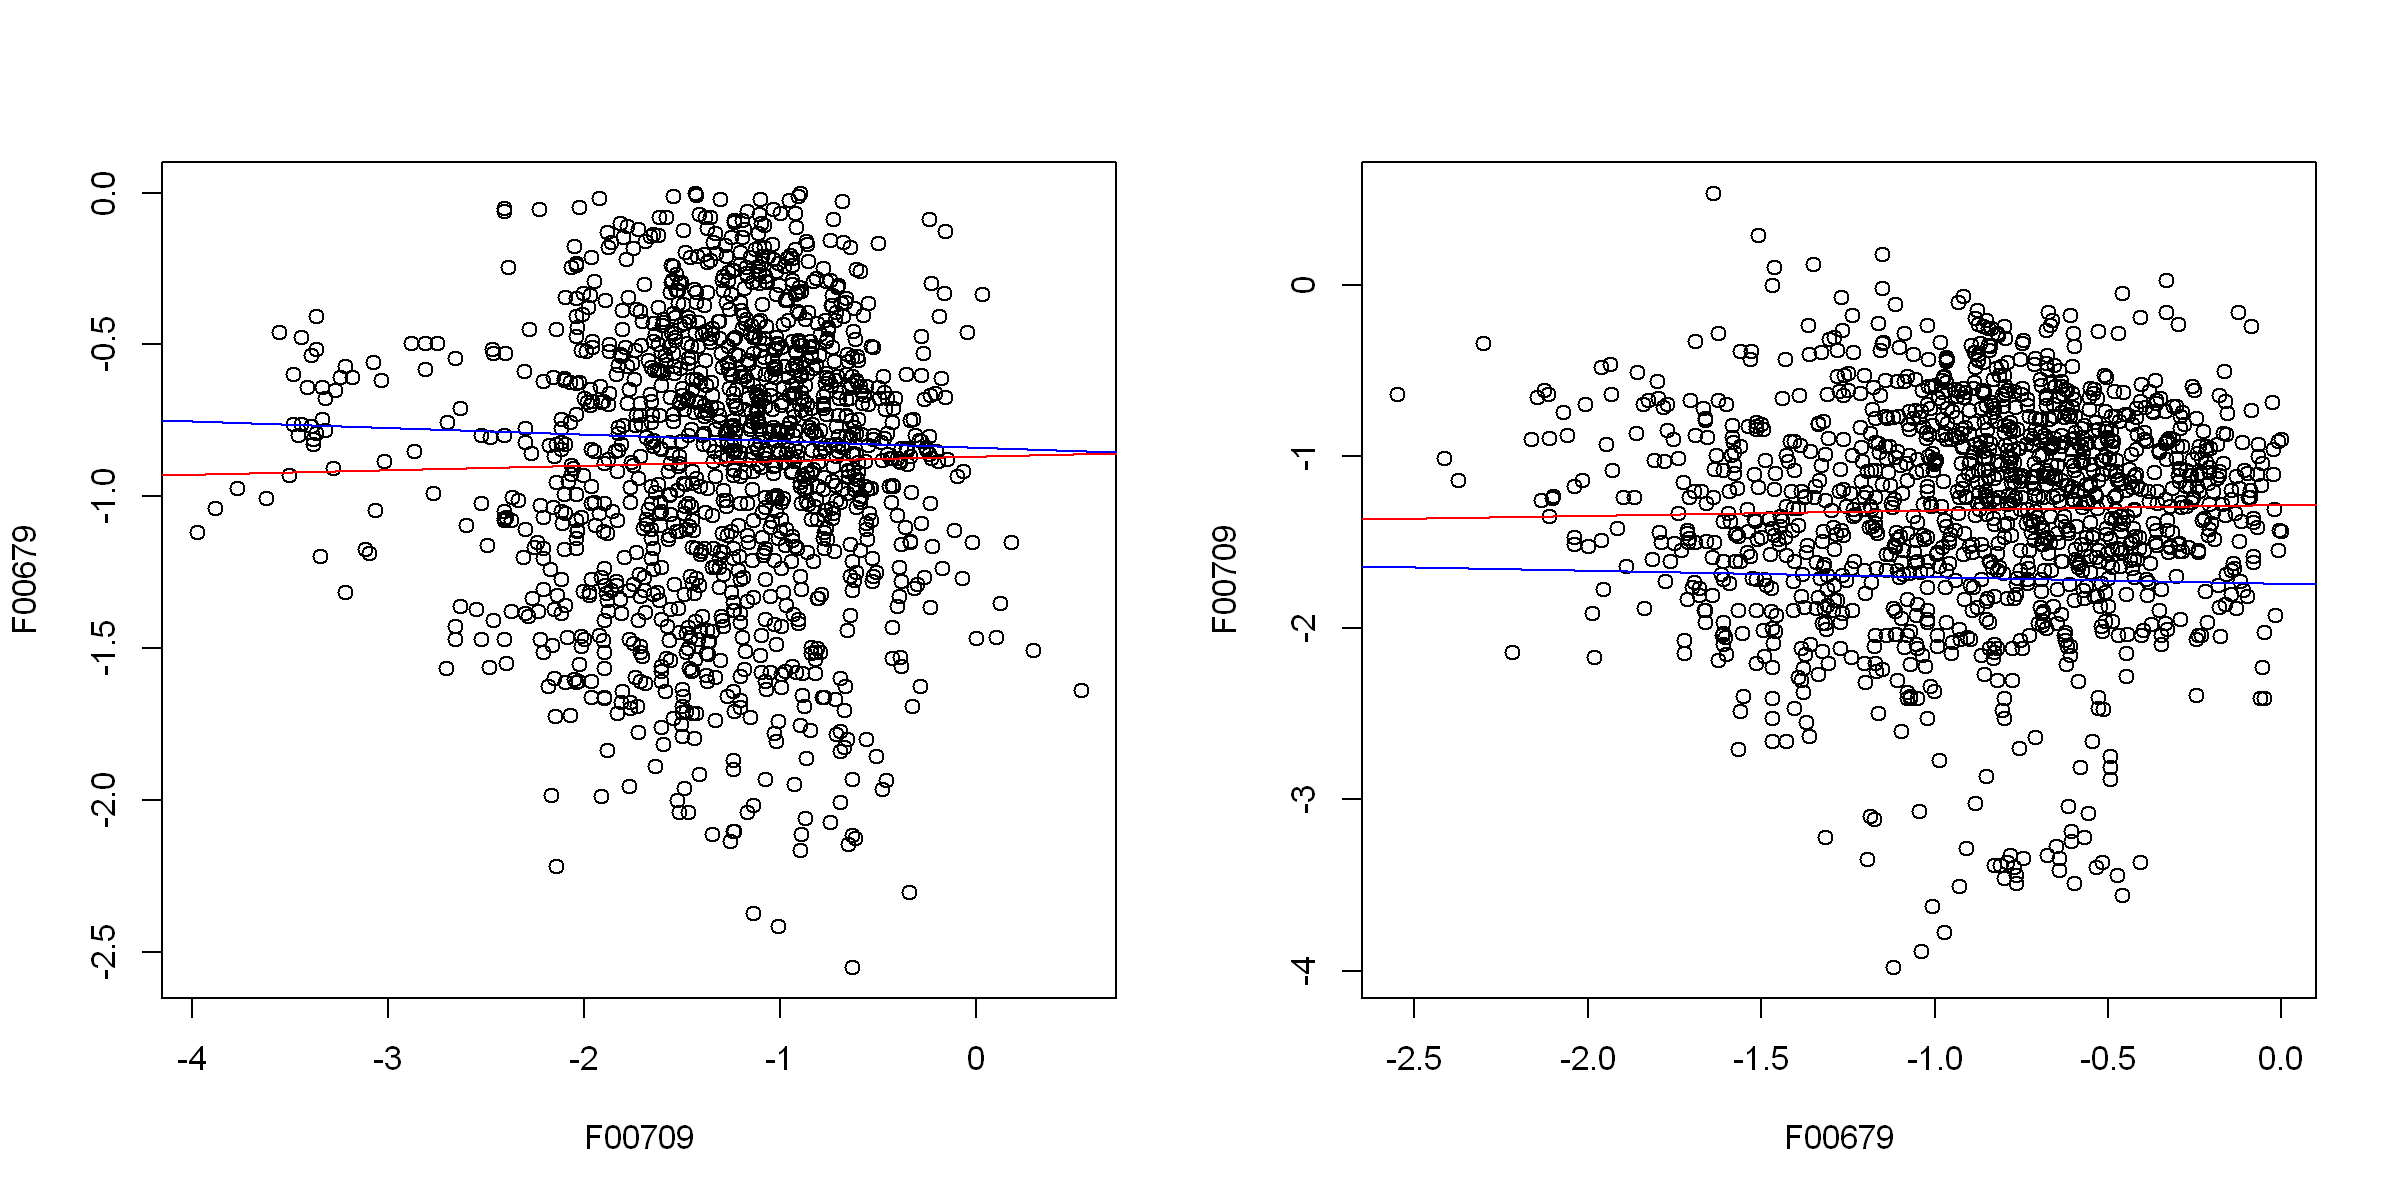

In [22]:
#------------
# RD & RTD
#------------

par(mfrow = c(1, 2))
plot(F00679 ~ F00709, data = traits)
abline(lm(F00679 ~ F00709, data = traits), col = "red")
abline(phylolm::phylolm(F00679 ~ F00709, data = traits, model = "lambda", phy = tree), col = "blue")

plot(F00709 ~ F00679, data = traits)
abline(lm(F00709 ~ F00679, data = traits), col = "red")
abline(phylolm::phylolm(F00709 ~ F00679, data = traits, model = "lambda", phy = tree), col = "blue")

In [120]:
# evern after accounting for phylogenetic relatedness, RD ~ SRL and SRL ~ RTD trait pairs show significant relationships
# so, next step, calculate how much phylogenetic signal is present in our continuous traits?? because the above could be a result of our dataset having little to no phylogenetic signal???

In [ ]:
# INVESTIGATE THE PHYLOGENETIC SIGNAL IN THE CONTINUOUS TRAITS
# since lambda was the best fitting model, use it to estimate the phylogenetic signal

physig_srl <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00727, nm = rownames(traits)))
physig_rd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00679, nm = rownames(traits)))
physig_rtd <- phytools::phylosig(tree = tree, method = "lambda", x = setNames(traits$F00709, nm = rownames(traits)))

In [44]:
tm # not bad at all :)

Time difference of 14.68104 mins

In [97]:
load("../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData") # reusing the serialized model fits

# for all the three continuous traits lambda seems to be the best model, followed by kappa and then OU??????

# AICc table
cbind(
    SRL = mapply(SRL_model_fits, FUN = function(m) m$opt$aicc),
    RD = mapply(RD_model_fits, FUN = function(m) m$opt$aicc),
    RTD = mapply(RTD_model_fits, FUN = function(m) m$opt$aicc)
)

,SRL,RD,RTD
BM,5194.320,2856.344,3753.738
OU,3929.309,1673.022,2363.545
EB,5196.349,2858.372,3755.767
rate_trend,5142.831,2805.895,3701.958
lambda,3411.727,1238.656,1939.839
kappa,3541.946,1414.510,2097.660
delta,5092.885,2757.039,3651.684
mean_trend,5196.329,2858.353,3755.747
white,4033.236,1702.775,2567.840


## ___`MR-PMM`___
---------------------

In [ ]:
# first, let's do a species level fit then we can worry about the genus level fits...




In [8]:
# "By including more diverse species in our phylogeny, we capture deeper splits that represent more meaningful divergences in the genotype and phenotype of extant lineages,
# precisely the effects we intend to model when analysing inter-species data."
# "One consequence of this, is that shallow topology (near the tips) is less informative than deep topology when attempting to infer patterns of phylogenetic niche conservatism, because differences between genera
# are usually more significant than differences between species within genera."

# "For higher taxonomic ranks (e.g. genus), it will usually be possible to derive a unique consensus tree by sampling a single species from each genus and simply pruning off the other tips from the tree.
# This approach may be problematic for lower taxonomic ranks however, because more closely related species are less likely to be monophyletic with respect to the taxonomic rank in question.
# Even in such cases, we can easily account for this phylogenetic uncertainty by randomly sampling topologies at the specified rank and fitting our models over this sample of trees."

In [16]:
# sample the phylogeny repeatedly, with one randomly chosen species per genera

NUNIQUE_GENERA <- length(unique(data$F01286)) # number of unique genera in our phylogeny
NSAMPLES = 100 # number of times to sample the original phylogeny
sampled_phylogenies <- list() # sampled sub phylogeneies with genera at tips
sampled_vcvs <- list()

for (i in 1:NSAMPLES) {
    sampled_species <- mapply(split.data.frame(data[, c("binominal", "F01286")], ~F01286), FUN = function(df) sample(df$binominal, 1)) # this is a vector of one randomly sampled species per each genera in the phylogeny
    subphylogeny <- ape::keep.tip(phy = phylogeny, tip = unname(sampled_species), trim.internal = TRUE) # trimmed phylogeny with one randomly sampled species per genus
    stopifnot(length(subphylogeny$tip.label)==NUNIQUE_GENERA)
                                     
    if(!ape::is.binary(subphylogeny)) subphylogeny <- ape::multi2di(subphylogeny) # make bifucracting if not already
    if(!ape::is.ultrametric(subphylogeny)) subphylogeny <- phytools::force.ultrametric(subphylogeny, method = "extend", message = FALSE) # make ultrametric if not already

    subphylogeny$tip.label <- gsub(subphylogeny$tip.label, pattern = "_[-a-z]+", replacement = '', fixed = FALSE) # replace the tip labels (binominal names) with genus names
    stopifnot(length(setdiff(subphylogeny$tip.label, unique(data$F01286))) == 0)
                              
    sampled_phylogenies[[i]] <- subphylogeny
    sampled_vcvs[[i]] <- ape::vcv.phylo(phy = subphylogeny, corr = TRUE) # computes the expected variances and covariances of a continuous phenotype assuming it evolves under a Brownian motion model
}

stopifnot(length(sampled_phylogenies) == length(sampled_vcvs))

In [ ]:
# create list of C matrices and dfs for use with brm_multiple() - DONT KNOW WTF THESE ARE????